In [1]:
# Importing essential libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
# Ensuring plots are displayed inline within the notebook
%matplotlib inline
import seaborn as sns

In [2]:
# Loading the cleaned dataset from the Excel file
df = pd.read_excel("Dados_Limpos.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1278 entries, 0 to 1277
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Unnamed: 0                 1278 non-null   int64         
 1   Source.Name                1278 non-null   object        
 2   ID                         1278 non-null   object        
 3   UUID do motorista          1278 non-null   object        
 4   Nome próprio do motorista  1278 non-null   object        
 5   Apelido do motorista       1278 non-null   object        
 6   UUID do veículo            1278 non-null   object        
 7   Matrícula                  1278 non-null   object        
 8   Tipo de serviço            1278 non-null   object        
 9   Distância da viagem        1278 non-null   float64       
 10  Estado da viagem           1278 non-null   object        
 11  Duracao                    1278 non-null   float64       
 12  Duraca

In [3]:
# Create a new column to calculate the Net Profit per Kilometer (Efficiency)
df['Euro_Km']= df['Lucro_Liquido']/df['Distância da viagem']

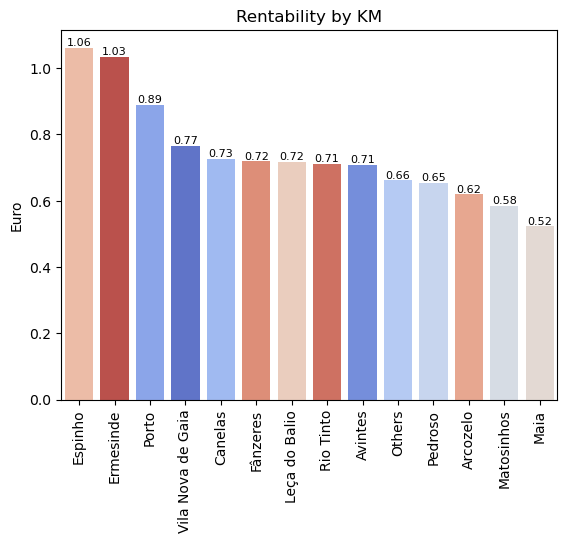

In [4]:
# create a new graph of rentability by KM
loc_count= df['nome_localidade_origem'].value_counts().sort_values(ascending=False)
loc_freq= loc_count[loc_count>10].index # Filter to select locations with more than 10 trips 
df_filter1=df[df['nome_localidade_origem'].isin(loc_freq)]
order_filter1 = df_filter1.groupby('nome_localidade_origem')['Euro_Km'].mean().sort_values(ascending=False).index #We apply the final filter to sort in descending order

graph_1=sns.barplot(
    data=df_filter1, 
    x='nome_localidade_origem', 
    y='Euro_Km', 
    hue='nome_localidade_origem',
    palette='coolwarm',
    errorbar=None, # Remove the black lines at the top of the bars
    order= order_filter1
)
plt.xlabel('')
plt.title('Rentability by KM')
plt.ylabel('Euro')
for bars in graph_1.containers: #Place the values at the top of each column and round them to two decimal places
    plt.bar_label(bars,size=8, fmt='%.2f') 
plt.xticks(rotation=90) # Rotate the names of the locations so they don't all overlap 
plt.savefig("Rentability by KM")
plt.show()

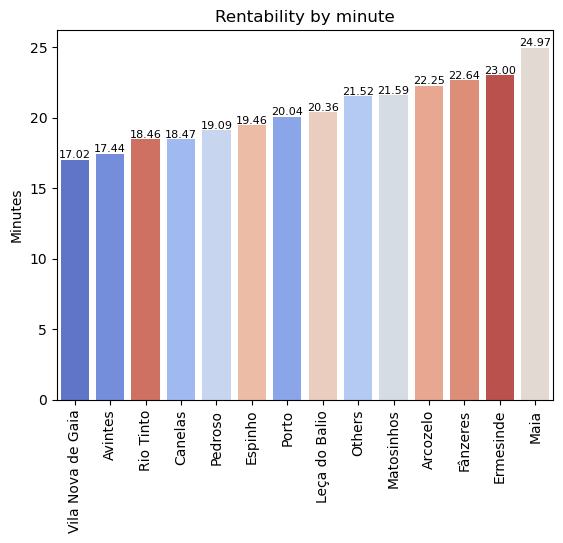

In [5]:
#Creating a profitability chart by the minute
#filter to sort from lowest to highest. The fewer minutes, the better.
ordem_tempo = df_filter1.groupby('nome_localidade_origem')['Duracao_Minutos'].mean().sort_values(ascending=True).index

graph_3 = sns.barplot(
    data=df_filter1, 
    x='nome_localidade_origem', 
    y='Duracao_Minutos', 
    hue='nome_localidade_origem', # Added to prevent the warning
    palette='coolwarm',           # A range from cold (fast) to hot (slow)
    errorbar=None,
    order=ordem_tempo,
)
for bars in graph_3.containers:
    plt.bar_label(bars,size=8, fmt='%.2f')
plt.xlabel('')
plt.title('Rentability by minute')
plt.ylabel('Minutes')
plt.xticks(rotation=90)
plt.savefig("Rentability by Min")
plt.show()

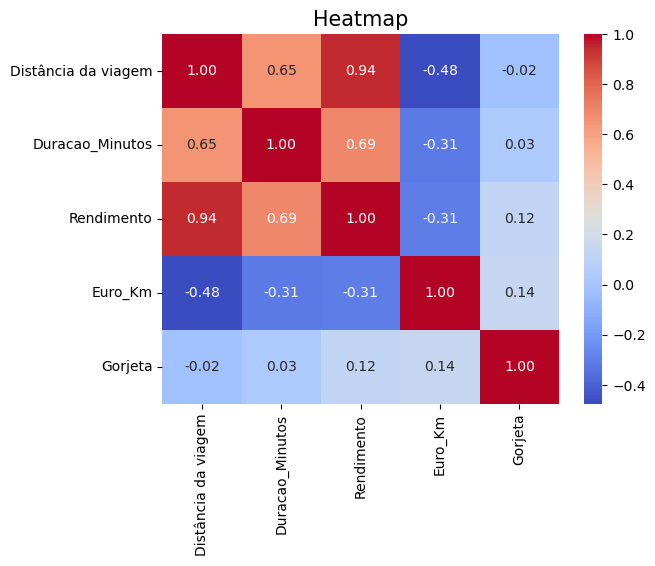

In [6]:
# Creating a heatmap to try to understand the correlation between the different variables
var_matriz=df[['Distância da viagem', 'Duracao_Minutos', 'Rendimento', 'Euro_Km', 'Gorjeta']] #Since not all values are numbers, I selected only those that contain numbers
matriz= var_matriz.corr() #The .corr() method performs a correlation between columns
#heatmap
sns.heatmap(
    matriz, 
    annot=True,       # Display the numbers inside the squares
    cmap='coolwarm',  # Blue for negative correlation, Red for positive
    fmt='.2f',        # Round to 2 decimal places
)

plt.title('Heatmap', fontsize=15)
plt.savefig("Heatmap")
plt.show()

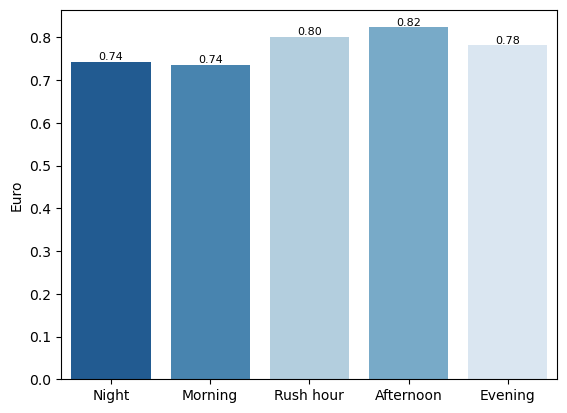

In [7]:
#filter to sort in descending order
order_filter2 = df.groupby('Period_of_Day')['Lucro_Liquido'].mean().sort_values(ascending=False).index

graph_2 = sns.barplot(
    data=df, 
    x='Period_of_Day', 
    y='Euro_Km', 
    hue='Period_of_Day',
    palette='Blues', # A color palette (from dark to light)
    errorbar=None,
    order = order_filter2
)
plt.xlabel('')
plt.ylabel('Euro')
for bars in graph_2.containers:
    plt.bar_label(bars,size=8, fmt='%.2f')
plt.savefig("Rentability by Period of the Day by Euro")
plt.show()

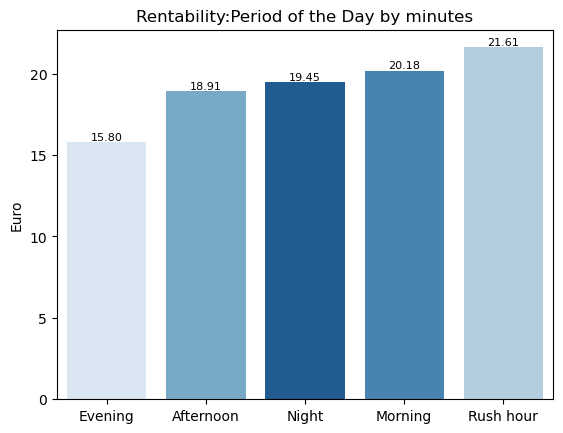

In [8]:
#filter to sort in descending order
order_filter4 = df.groupby('Period_of_Day')['Duracao_Minutos'].mean().sort_values(ascending=True).index

graph_4 = sns.barplot(
    data=df, 
    x='Period_of_Day', 
    y='Duracao_Minutos', 
    hue='Period_of_Day',
    palette='Blues', # A color palette (from dark to light)
    errorbar=None,
    order = order_filter4
)
plt.title('Rentability:Period of the Day by minutes')
plt.xlabel('')
plt.ylabel('Euro')
for bars in graph_4.containers:
    plt.bar_label(bars,size=8, fmt='%.2f')
plt.savefig("Rentability:Period of the day by Minutes")
plt.show()

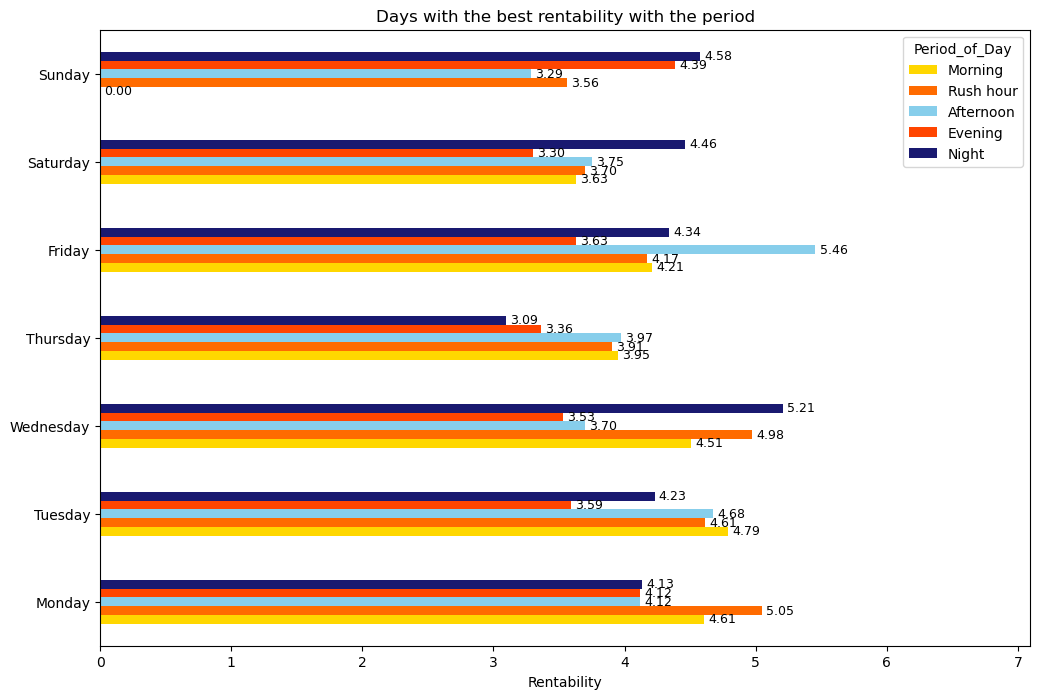

In [9]:
#Creating a pivot table to identify patterns and determine which days have the highest revenue by time of day
tabela_pivot = df.pivot_table(index='Week_Day', 
                              columns='Period_of_Day', 
                              values='Lucro_Liquido', 
                              aggfunc='mean')
#I organized both the days of the week and the periods to create a logical order
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

tabela_pivot = tabela_pivot.reindex(ordem_dias)

ordem_periodos = ['Morning', 'Rush hour', 'Afternoon', 'Evening', 'Night']

tabela_pivot = tabela_pivot.reindex(columns=ordem_periodos)

#I was having trouble reading the numbers on the graph, so I made them bigger
fig, ax = plt.subplots(figsize=(12, 8))

color_graph_5=cores = {
    'Morning': '#FFD700',    # yellow - dawn
    'Rush hour': '#FF6B00',  # orange - rush hour
    'Afternoon': '#87CEEB',  # light blue - afternoon
    'Evening': '#FF4500',    # orange-red - end of the day
    'Night': '#191970'       # dark blue - night
}

graph_5=tabela_pivot.plot.barh(
    title= 'Days with the best rentability with the period',
    ax=ax,
    color=color_graph_5
    )
plt.xlabel('Rentability')
plt.ylabel('')
plt.margins(x=0.30)
for bars in graph_5.containers:
    plt.bar_label(bars,size=9, fmt='%.2f',padding=3)
plt.savefig("Days with the best rentability")
plt.show()

C:\Users\joaov\AppData\Local\Temp\ipykernel_12604\3724982946.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  graph_6 = sns.barplot(


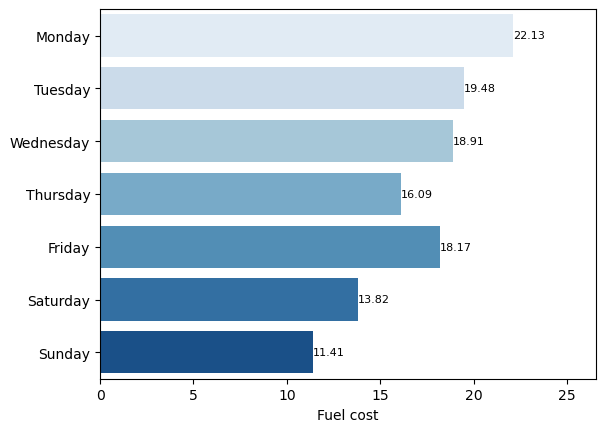

In [10]:
#Groups all trips to know the the total fuel cost per day
custo_por_dia = df.groupby('Data')['Custo_Combustivel'].sum().reset_index()
custo_por_dia['Week_Day'] = pd.to_datetime(custo_por_dia['Data']).dt.day_name()

graph_6 = sns.barplot(
    data=custo_por_dia, 
    x='Custo_Combustivel', 
    y='Week_Day', 
    palette='Blues',
    errorbar=None,
    estimator='mean',
    order=ordem_dias
)
plt.xlabel('Fuel cost')
plt.ylabel('')
plt.margins(x=0.20)
for bars in graph_6.containers:
    plt.bar_label(bars,size=8, fmt='%.2f')
plt.savefig("Fuel cost by the week day")
plt.show()

C:\Users\joaov\AppData\Local\Temp\ipykernel_12604\4240321768.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  graph_7 = sns.barplot(


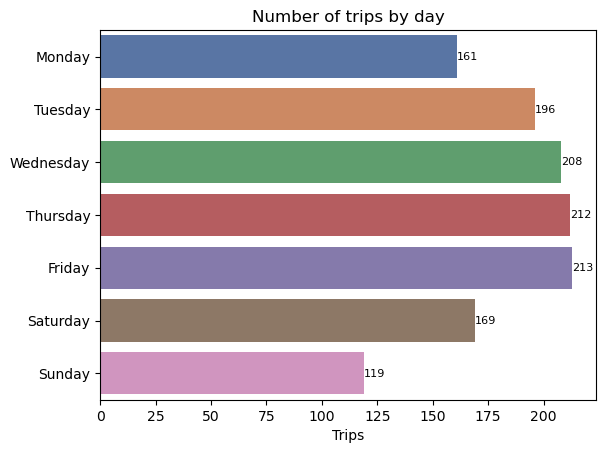

In [11]:
#Counts all trips and groups by week of the day.
viagens_por_dia = df.groupby('Week_Day')['ID'].count().reset_index()
viagens_por_dia.columns = ['Week_Day', 'N_Viagens'] #gives the name N_Viagens to the counted trips

graph_7 = sns.barplot(
    data=viagens_por_dia,
    x='N_Viagens',
    y='Week_Day',
    palette='deep',
    errorbar=None,
    order=ordem_dias
)
plt.title('Number of trips by day')
plt.xlabel('Trips')
plt.ylabel('')
for bars in graph_7.containers:
    plt.bar_label(bars, size=8, fmt='%.0f')
plt.savefig("Number of Trips by day")
plt.show()

In [12]:
# Group by Week_day and calculate the mean distance of trips and the mean rentability.
df.groupby('Week_Day').agg(
    distance_mean=('Distância da viagem', 'mean'),
    rentability_mean=('Rendimento', 'mean')
).reindex(ordem_dias).round(2)

,distance_mean,rentability_mean
Week_Day,,
Monday,8.67,5.70
Tuesday,7.67,5.46
Wednesday,7.65,5.40
Thursday,6.39,4.63
Friday,7.18,5.13
Saturday,6.31,4.55
Sunday,6.72,4.88
